500ノードのグラフを生成します...
PageRankの計算が完了しました。
Node2Vecによる埋め込みを開始します...
Node2Vecの埋め込みが完了しました。
Poincare Modelによる双曲埋め込みを開始します...
双曲埋め込みが完了しました。
結果を可視化します...


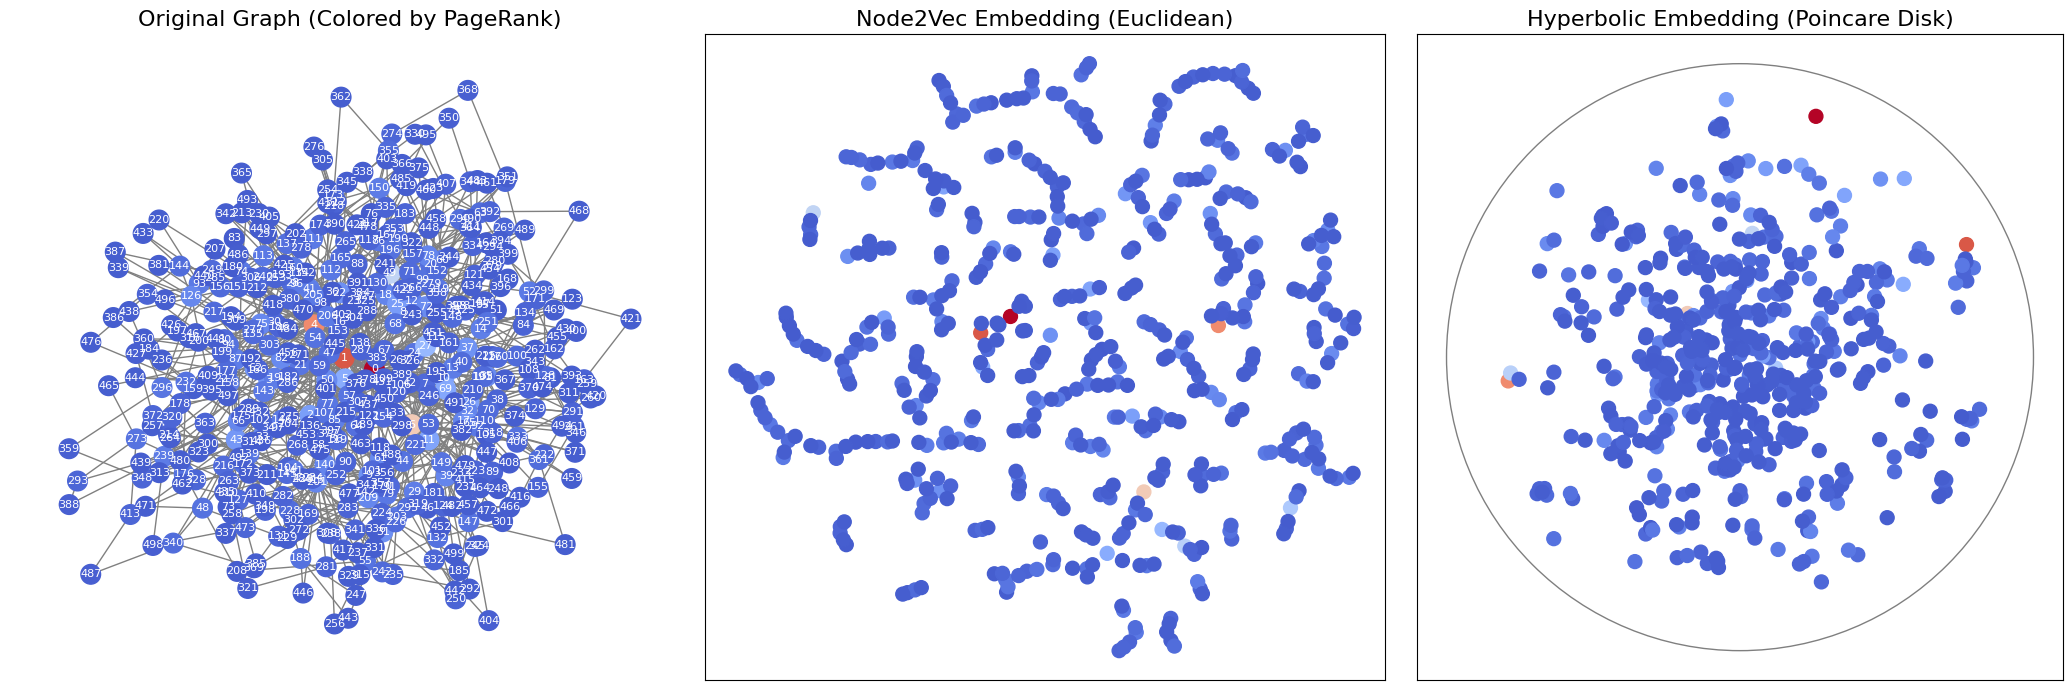

実験完了。


In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from node2vec import Node2Vec
from gensim.models.poincare import PoincareModel
from matplotlib.patches import Circle

# --- 1. パラメータ設定 ---
NUM_NODES = 500  # 生成するグラフのノード数
EDGE_PROB = 0.1 # Barabasi-Albertモデル用のパラメータ (新規ノードが接続するエッジ数)

print(f"{NUM_NODES}ノードのグラフを生成します...")

# --- 2. グラフの生成とPageRankの計算 ---
# Barabasi-Albertモデルでスケールフリーネットワークを生成
# 中心的なノード（ハブ）が生まれやすい
G = nx.barabasi_albert_graph(n=NUM_NODES, m=2, seed=42)

# PageRankを計算
pagerank = nx.pagerank(G)
# PageRankの値を色付けのためにリスト化
pagerank_values = np.array([pagerank[i] for i in G.nodes()])

print("PageRankの計算が完了しました。")

# --- 3. 埋め込みの実行 ---

# (A) Node2Vec (ユークリッド埋め込み)
print("Node2Vecによる埋め込みを開始します...")
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, quiet=True)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)
# 高次元ベクトルをt-SNEで2次元に削減
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embedding_n2v_2d = tsne.fit_transform(model_n2v.wv.vectors)
print("Node2Vecの埋め込みが完了しました。")


# (B) Poincaré Model (双曲埋め込み)
print("Poincare Modelによる双曲埋め込みを開始します...")
# gensimのモデルはエッジリストを必要とする
edges = [tuple(edge) for edge in G.edges()]
model_hyp = PoincareModel(train_data=edges, size=2, negative=5) # size=2で直接2次元に埋め込む
model_hyp.train(epochs=50, print_every=1000)
embedding_hyp_2d = model_hyp.kv.vectors
print("双曲埋め込みが完了しました。")


# --- 4. 結果の可視化 ---
print("結果を可視化します...")
fig = plt.figure(figsize=(21, 7))
plt.style.use('default')

# (1) 元のグラフとPageRank
ax1 = fig.add_subplot(1, 3, 1)
pos = nx.spring_layout(G, seed=42) # ノードの配置を決定
# PageRankの値に応じて色を決定 (低い:青 -> 高い:赤)
colors = cm.coolwarm(pagerank_values / pagerank_values.max())
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=200, ax=ax1, font_color='white', font_size=8, edge_color='gray')
ax1.set_title("Original Graph (Colored by PageRank)", fontsize=16)

# (2) Node2Vec (t-SNEで2次元化)
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(embedding_n2v_2d[:, 0], embedding_n2v_2d[:, 1], c=colors, s=100)
ax2.set_title("Node2Vec Embedding (Euclidean)", fontsize=16)
ax2.set_xticks([])
ax2.set_yticks([])

# (3) Hyperbolic Embedding (Poincaré Disk)
ax3 = fig.add_subplot(1, 3, 3)
# ポアンカレ円盤の縁を描画
circle = Circle((0, 0), 1, facecolor='none', edgecolor='black', linewidth=1, alpha=0.5)
ax3.add_patch(circle)
ax3.scatter(embedding_hyp_2d[:, 0], embedding_hyp_2d[:, 1], c=colors, s=100, zorder=2) # zorderで点を円より手前に
ax3.set_title("Hyperbolic Embedding (Poincare Disk)", fontsize=16)
ax3.set_xlim(-1.1, 1.1)
ax3.set_ylim(-1.1, 1.1)
ax3.set_aspect('equal', adjustable='box')
ax3.set_xticks([])
ax3.set_yticks([])


plt.tight_layout()
plt.show()

print("実験完了。")

## Save the figure if needed
fig.savefig("output/graph_embedding_results.png", dpi=300, bbox_inches='tight')


50ノードの有向グラフを生成します...
PageRankの計算が完了しました。
Node2Vecによる埋め込みを開始します...
Node2Vecの埋め込みが完了しました。
Poincare Modelによる双曲埋め込みを開始します...
双曲埋め込みが完了しました。
結果を可視化します...


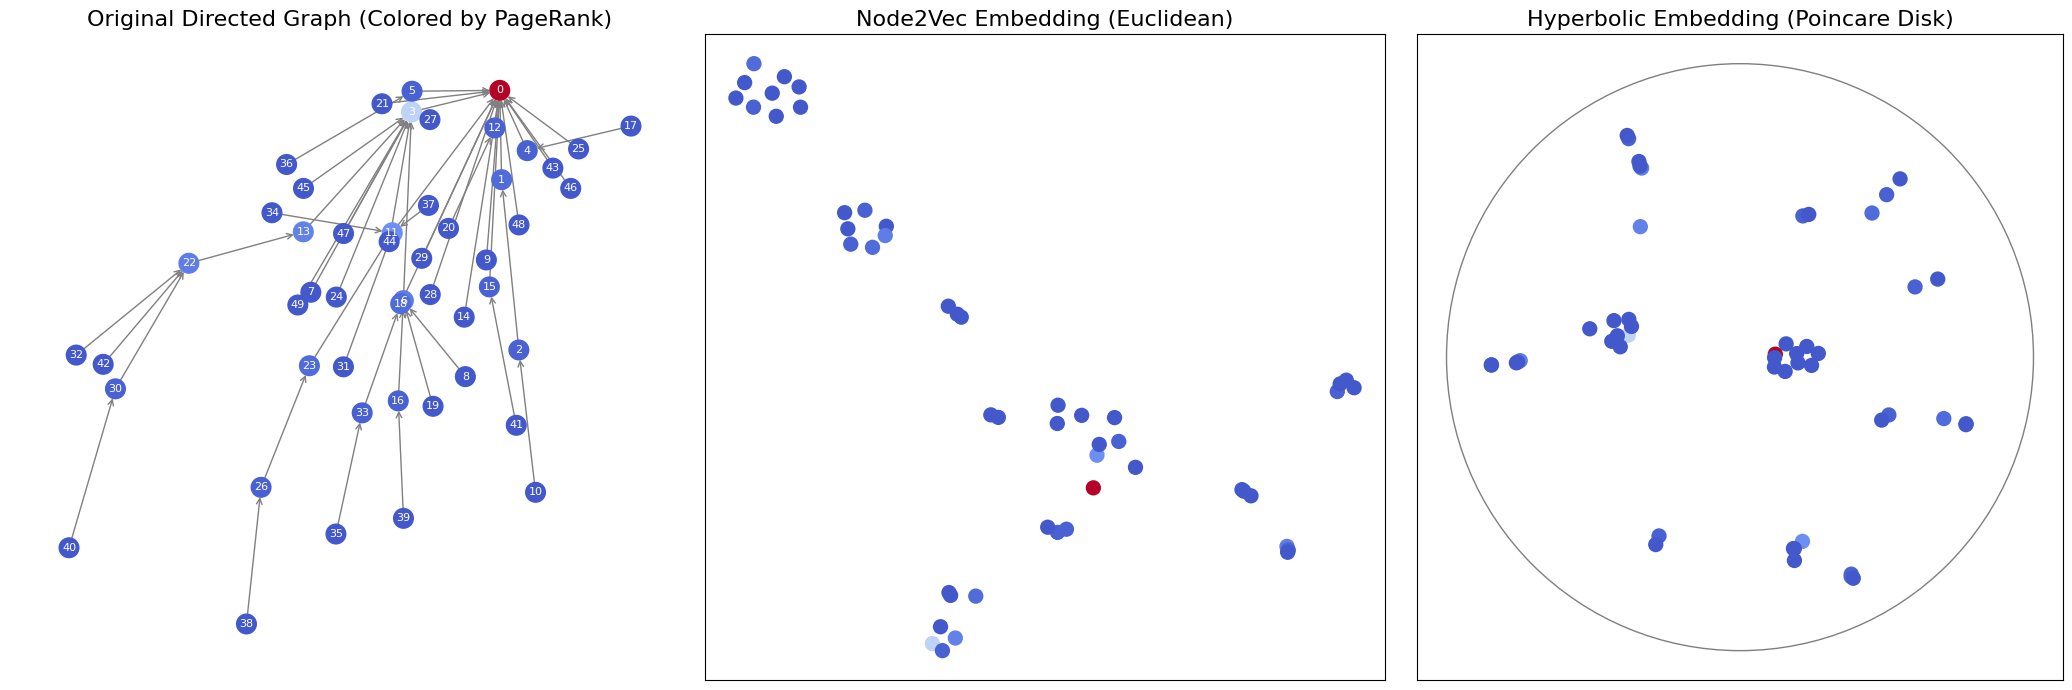

実験完了。


In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from node2vec import Node2Vec
from gensim.models.poincare import PoincareModel
from matplotlib.patches import Circle

# --- 1. パラメータ設定 ---
NUM_NODES = 50  # 生成するグラフのノード数

print(f"{NUM_NODES}ノードの有向グラフを生成します...")

# --- 2. 有向グラフの生成とPageRankの計算 ---
# gn_graphで有向のスケールフリーネットワークを生成
# このモデルはデフォルトで nx.DiGraph (有向グラフ) オブジェクトを返す
G = nx.gn_graph(n=NUM_NODES, seed=42)

# PageRankを計算 (PageRankは本来、有向グラフのためのアルゴリズム)
pagerank = nx.pagerank(G)
# PageRankの値を色付けのためにリスト化
pagerank_values = np.array([pagerank.get(i, 0) for i in G.nodes()]) # .getでキーが存在しない場合に対応

print("PageRankの計算が完了しました。")

# --- 3. 埋め込みの実行 ---

# (A) Node2Vec (ユークリッド埋め込み)
# Node2Vecはグラフが有向か無向かを自動で判断し、ウォークの方向を制限する
print("Node2Vecによる埋め込みを開始します...")
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4, quiet=True)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)
# 高次元ベクトルをt-SNEで2次元に削減
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embedding_n2v_2d = tsne.fit_transform(model_n2v.wv.vectors)
print("Node2Vecの埋め込みが完了しました。")


# (B) Poincaré Model (双曲埋め込み)
# PoincareModelは有向エッジ (A, B) を「AがBを包含する」階層関係として解釈する
print("Poincare Modelによる双曲埋め込みを開始します...")
edges = [tuple(edge) for edge in G.edges()]
model_hyp = PoincareModel(train_data=edges, size=2, negative=5)
model_hyp.train(epochs=50, print_every=1000)
# PoincareModelは学習データに含まれるノードしかベクトルを持たないため、G.nodes()で全ノードのベクトルを取得
embedding_hyp_2d = np.array([model_hyp.kv.get_vector(n) for n in G.nodes()])
print("双曲埋め込みが完了しました。")


# --- 4. 結果の可視化 ---
print("結果を可視化します...")
fig = plt.figure(figsize=(21, 7))
plt.style.use('default')

# (1) 元のグラフとPageRank
ax1 = fig.add_subplot(1, 3, 1)
pos = nx.spring_layout(G, seed=42)
# PageRankの値に応じて色を決定 (低い:青 -> 高い:赤)
colors = cm.coolwarm(pagerank_values / pagerank_values.max())
# arrows=True を追加して矢印を描画
nx.draw(
    G, pos, with_labels=True, node_color=colors, node_size=200, ax=ax1,
    font_color='white', font_size=8, edge_color='gray',
    arrows=True, arrowstyle='->', arrowsize=10
)
ax1.set_title("Original Directed Graph (Colored by PageRank)", fontsize=16)

# (2) Node2Vec (t-SNEで2次元化)
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(embedding_n2v_2d[:, 0], embedding_n2v_2d[:, 1], c=colors, s=100)
ax2.set_title("Node2Vec Embedding (Euclidean)", fontsize=16)
ax2.set_xticks([])
ax2.set_yticks([])

# (3) Hyperbolic Embedding (Poincaré Disk)
ax3 = fig.add_subplot(1, 3, 3)
circle = Circle((0, 0), 1, facecolor='none', edgecolor='black', linewidth=1, alpha=0.5)
ax3.add_patch(circle)
ax3.scatter(embedding_hyp_2d[:, 0], embedding_hyp_2d[:, 1], c=colors, s=100, zorder=2)
ax3.set_title("Hyperbolic Embedding (Poincare Disk)", fontsize=16)
ax3.set_xlim(-1.1, 1.1)
ax3.set_ylim(-1.1, 1.1)
ax3.set_aspect('equal', adjustable='box')
ax3.set_xticks([])
ax3.set_yticks([])


plt.tight_layout()
plt.show()

print("実験完了。")

In [10]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
from sklearn.manifold import TSNE
from node2vec import Node2Vec
from gensim.models.poincare import PoincareModel
from gensim.models import Word2Vec
from karateclub.node_embedding.structural import Struc2Vec
from matplotlib.patches import Circle

# --- 1. パラメータ設定 ---
NUM_NODES = 50

print(f"{NUM_NODES}ノードの有向グラフを生成します...")

# --- 2. 有向グラフの生成とPageRankの計算 ---
G = nx.gn_graph(n=NUM_NODES, seed=42)
pagerank = nx.pagerank(G)
pagerank_values = np.array([pagerank.get(i, 0) for i in G.nodes()])

print("PageRankの計算が完了しました。")

# --- 3. 埋め込みの実行 ---

# (A) Node2Vec (ユークリッド埋め込み)
print("Node2Vecによる埋め込みを開始します...")
node2vec = Node2Vec(G, dimensions=16, walk_length=30, num_walks=200, workers=4, quiet=True)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)
embedding_n2v = np.array([model_n2v.wv.get_vector(str(n)) for n in G.nodes()])
print("Node2Vec完了。")

# (B) Poincaré Model (双曲埋め込み)
print("Poincare Modelによる双曲埋め込みを開始します...")
edges = [tuple(map(str, edge)) for edge in G.edges()]
model_hyp = PoincareModel(train_data=edges, size=2, negative=5)
model_hyp.train(epochs=50, print_every=1000)
embedding_hyp = np.array([model_hyp.kv.get_vector(str(n)) for n in G.nodes()])
print("双曲埋め込み完了。")

# (C) Struc2Vec (構造的類似性に基づく埋め込み)
print("Struc2Vecによる埋め込みを開始します...")
struc2vec = Struc2Vec(dimensions=16)
struc2vec.fit(G)
embedding_s2v = struc2vec.get_embedding()
# karateclubはノード順にベクトルを返すのでソートは不要
print("Struc2Vec完了。")

# (D) Word2Vec (ランダムウォークに基づく埋め込み)
print("Word2Vecのためのランダムウォークを生成します...")
def generate_random_walks(graph, num_walks, walk_length):
    walks = []
    for _ in range(num_walks):
        for node in graph.nodes():
            walk = [str(node)]
            current_node = node
            for _ in range(walk_length - 1):
                neighbors = list(graph.successors(current_node))
                if len(neighbors) == 0:
                    break
                current_node = random.choice(neighbors)
                walk.append(str(current_node))
            walks.append(walk)
    return walks

walks = generate_random_walks(G, 80, 10)
print("Word2Vecモデルを学習します...")
model_w2v = Word2Vec(sentences=walks, vector_size=16, window=5, min_count=1, workers=4)
embedding_w2v = np.array([model_w2v.wv.get_vector(str(n)) for n in G.nodes()])
print("Word2Vec完了。")


# --- 4. t-SNEによる次元削減 ---
print("t-SNEによる次元削減を実行します...")
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embedding_n2v_2d = tsne.fit_transform(embedding_n2v)
embedding_s2v_2d = tsne.fit_transform(embedding_s2v)
embedding_w2v_2d = tsne.fit_transform(embedding_w2v)
# Poincareは元から2次元なのでt-SNEは不要
embedding_hyp_2d = embedding_hyp

# --- 5. 結果の可視化 ---
print("結果を可視化します...")
fig = plt.figure(figsize=(35, 7)) # 横幅を広げる
plt.style.use('default')

# 配色を決定
colors = cm.coolwarm(pagerank_values / max(1e-9, pagerank_values.max()))

# (1) 元のグラフ
ax1 = fig.add_subplot(1, 5, 1)
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=200, ax=ax1,
        font_color='white', font_size=8, edge_color='gray', arrows=True, arrowstyle='->', arrowsize=10)
ax1.set_title("Original Directed Graph", fontsize=16)

# (2) Node2Vec
ax2 = fig.add_subplot(1, 5, 2)
ax2.scatter(embedding_n2v_2d[:, 0], embedding_n2v_2d[:, 1], c=colors, s=100)
ax2.set_title("Node2Vec Embedding", fontsize=16)
ax2.set_xticks([]); ax2.set_yticks([])

# (3) Hyperbolic
ax3 = fig.add_subplot(1, 5, 3)
circle = Circle((0, 0), 1, facecolor='none', edgecolor='black', alpha=0.5)
ax3.add_patch(circle)
ax3.scatter(embedding_hyp_2d[:, 0], embedding_hyp_2d[:, 1], c=colors, s=100, zorder=2)
ax3.set_title("Hyperbolic Embedding", fontsize=16)
ax3.set_xlim(-1.1, 1.1); ax3.set_ylim(-1.1, 1.1)
ax3.set_aspect('equal', adjustable='box')
ax3.set_xticks([]); ax3.set_yticks([])

# (4) Struc2Vec
ax4 = fig.add_subplot(1, 5, 4)
ax4.scatter(embedding_s2v_2d[:, 0], embedding_s2v_2d[:, 1], c=colors, s=100)
ax4.set_title("Struc2Vec Embedding", fontsize=16)
ax4.set_xticks([]); ax4.set_yticks([])

# (5) Word2Vec
ax5 = fig.add_subplot(1, 5, 5)
ax5.scatter(embedding_w2v_2d[:, 0], embedding_w2v_2d[:, 1], c=colors, s=100)
ax5.set_title("Word2Vec (from Walks)", fontsize=16)
ax5.set_xticks([]); ax5.set_yticks([])


plt.tight_layout()
plt.show()

print("実験完了。")

ImportError: cannot import name 'Struc2Vec' from 'karateclub.node_embedding.structural' (/home/lab/ryoma/master/envs/pems-metra/lib/python3.11/site-packages/karateclub/node_embedding/structural/__init__.py)